# Fashion-MNIST Neural network

Importing nessecary modules:

In [1]:
import torch
from torch import nn #Model architecture module

import torchvision #Handling image data
from torchvision import datasets
from torchvision.transforms import ToTensor, Normalize, Compose

import numpy as np #array operations
import matplotlib.pyplot as plt #data visualisation


Setting seed to reduce noise during training

In [2]:
seed = 1
np.random.seed(seed)
torch.manual_seed(seed)

In [3]:
train_data = datasets.FashionMNIST(root='FashionMNIST_data', train = True, download = True, transform = ToTensor()) #download and load training data to tensors
print(train_data[0][0].shape) #Shape of image in first data point

100%|██████████| 26.4M/26.4M [00:01<00:00, 17.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 305kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.61MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 8.86MB/s]

torch.Size([1, 28, 28])


Image Preprocessing

In [4]:
pixel_data = torch.stack([img for img, label in train_data]) #stacked tensor of all images in train_data
mean = pixel_data.mean().item()
std = pixel_data.std().item()
print(f'Mean: {mean}, Std: {std}')
transform = Compose([
    ToTensor(),
    Normalize((mean,), (std,)) #Standardisation- Mean is 0 and std deviation is 1
])


Mean: 0.2860405743122101, Std: 0.3530242443084717


Load train and test data with standardisation

In [5]:
train_data = datasets.FashionMNIST(root='FashionMNIST_data', train = True, download = True, transform = transform)
test_data = datasets.FashionMNIST(root='FashionMNIST_data', train = False, download = True, transform = transform)
data_labels = train_data.classes

Loading data into batches

In [6]:
from torch.utils.data import DataLoader

batch_size = 64

train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=False)


**Main model architecture**

In [7]:
import torch.nn.functional as F


In [8]:
class MNISTmodel(nn.Module):
  def __init__(self):
    super().__init__()

    self.fc1 = nn.Linear(in_features=784, out_features=16)

    #Left branch
    self.fcl1 = nn.Linear(in_features=16, out_features=8)
    self.fcl2 = nn.Linear(in_features=8, out_features=8)

    #Right branch
    self.fcr1 = nn.Linear(in_features=16, out_features=12)
    self.fcr2 = nn.Linear(in_features=12, out_features=8)

    #Output branch
    self.out = nn.Linear(in_features=16, out_features=10)

    self.dropout = nn.Dropout(0.2) # to reduce overfitting

  def forward(self, x): #Base forward propogation without Dropout or batch regularisation
    x = x.view(x.shape[0],-1) #flattening batch of images to 784 nodes(pixels) | here, 64x28x28 to 64x784

    x = F.relu(self.fc1(x))

    #Left branch (Skip connection layers)

    x1 = F.relu(self.fcl1(x))
    res_node = x1 #Residual node for skip connection
    x1 = F.relu(self.fcl2(x1))
    x1 = F.relu(x1 + res_node) # skip connection add

    #Right branch
    x2 = F.relu(self.fcr1(x))
    x2 = F.relu(self.fcr2(x2))

    #concatenate
    x_comb = torch.cat((x1,x2), dim=1) #'adding' both branches

    x = F.log_softmax(self.out(x_comb),dim=1)

    return x


In [9]:
!pip install torchinfo #for model summary

In [10]:
from torchinfo import summary

Model summary:

In [11]:
model = MNISTmodel()
print(summary(model, input_size=(1,1,28,28)))

Layer (type:depth-idx)                   Output Shape              Param #
MNISTmodel                               [1, 10]                   --
├─Linear: 1-1                            [1, 16]                   12,560
├─Linear: 1-2                            [1, 8]                    136
├─Linear: 1-3                            [1, 8]                    72
├─Linear: 1-4                            [1, 12]                   204
├─Linear: 1-5                            [1, 8]                    104
├─Linear: 1-6                            [1, 10]                   170
Total params: 13,246
Trainable params: 13,246
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.05
Estimated Total Size (MB): 0.06


In [12]:
def train_model(model, train_dataloader, loss_func, optimizer, device):
  model.train() #training mode for model (internally)

  model.to(device)

  net_loss = 0
  total_samples = 0
  correct = 0

  for images,labels in train_dataloader:
    images = images.to(device)
    labels = labels.to(device)

    output = model(images)

    loss = loss_func(output, labels)
    loss.backward()

    optimizer.step()
    optimizer.zero_grad() #reset gradient to 0 after each batch

    net_loss += loss.item()

    _, prediction = torch.max(output.data, dim = 1) #label with highest prediction value

    total_samples += labels.size(0)
    correct += (prediction == labels).sum().item()

  avg_loss = net_loss/len(train_dataloader)
  accuracy = correct/total_samples

  return avg_loss, accuracy


In [13]:
import csv

In [14]:
def test_model(model, test_dataloader, loss_func, device):
  model.eval()
  model.to(device)

  net_loss = 0
  total_samples = 0
  correct = 0
  predicted_labels = []
  actual_labels = []
  with torch.inference_mode(): #disabling tensor operation tracking | newer version of torch.no_grad()
    for images,labels in test_dataloader:
      images = images.to(device)
      labels = labels.to(device)

      output = model(images)

      loss = loss_func(output, labels)
      net_loss += loss.item()

      _, prediction = torch.max(output.data, dim = 1) #label with highest prediction value

      total_samples += labels.size(0)
      correct += (prediction == labels).sum().item()
      predicted_labels.extend(prediction.cpu().numpy())
      actual_labels.extend(labels.cpu().numpy())

  avg_loss = net_loss/len(test_dataloader)
  accuracy = correct/total_samples
  with open('submissions.csv', mode='w', newline = '') as file:
    writer = csv.writer(file)
    writer.writerow(['Serial no.','Predicted Label', 'Actual Label'])
    for i in range(len(predicted_labels)):
      writer.writerow([i+1, predicted_labels[i], actual_labels[i]])
  return avg_loss, accuracy


In [15]:
import pickle #saving model weights

In [16]:
def main(model, train_dataloader, test_dataloader, loss_func, optimizer, epochs, device, save = True, visualize = True):
  train_losses = []
  train_accuracies = []
  test_losses = []
  test_accuracies = []
  for epoch in range(epochs):
    train_loss, train_acc = train_model(model, train_dataloader, loss_func, optimizer, device)
    test_loss, test_acc = test_model(model, test_dataloader, loss_func, device)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

  if save:
    with open("model_weights.pkl", "wb") as f:
      pickle.dump(model.state_dict(), f)
    print('Model weights saved.')

  if visualize:
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(train_accuracies, label='Train Accuracy')
    plt.plot(test_accuracies, label='Test Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.savefig(f'loss_accuracy_{epochs}epochs.png')
    plt.show()


Available device is: cpu
Epoch 1/20 | Train Loss: 0.7228 | Train Acc: 0.7426 | Test Loss: 0.5219 | Test Acc: 0.8125
Epoch 2/20 | Train Loss: 0.4534 | Train Acc: 0.8413 | Test Loss: 0.4656 | Test Acc: 0.8330
Epoch 3/20 | Train Loss: 0.4207 | Train Acc: 0.8510 | Test Loss: 0.4463 | Test Acc: 0.8418
Epoch 4/20 | Train Loss: 0.4008 | Train Acc: 0.8572 | Test Loss: 0.4308 | Test Acc: 0.8456
Epoch 5/20 | Train Loss: 0.3862 | Train Acc: 0.8617 | Test Loss: 0.4174 | Test Acc: 0.8534
Epoch 6/20 | Train Loss: 0.3745 | Train Acc: 0.8655 | Test Loss: 0.4254 | Test Acc: 0.8476
Epoch 7/20 | Train Loss: 0.3645 | Train Acc: 0.8690 | Test Loss: 0.4161 | Test Acc: 0.8484
Epoch 8/20 | Train Loss: 0.3566 | Train Acc: 0.8724 | Test Loss: 0.4054 | Test Acc: 0.8579
Epoch 9/20 | Train Loss: 0.3494 | Train Acc: 0.8735 | Test Loss: 0.4000 | Test Acc: 0.8563
Epoch 10/20 | Train Loss: 0.3438 | Train Acc: 0.8765 | Test Loss: 0.4051 | Test Acc: 0.8562
Epoch 11/20 | Train Loss: 0.3385 | Train Acc: 0.8783 | Test Loss

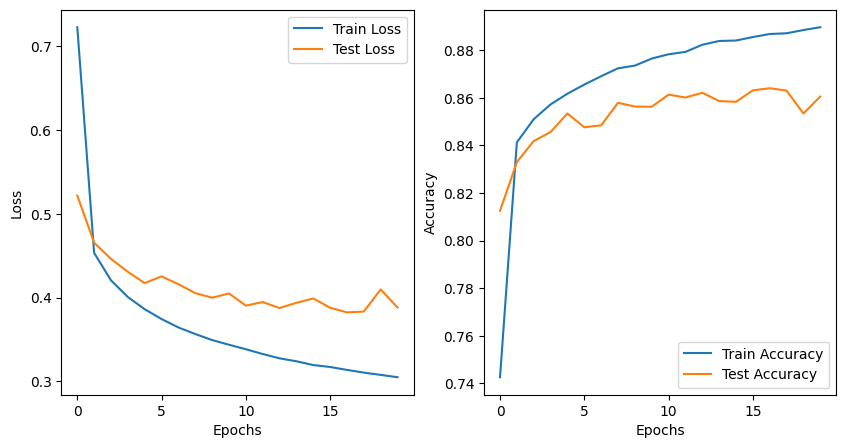

In [17]:
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.0005)
epochs = 20

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Available device is: {device}")


main(model, train_dataloader, test_dataloader, loss_func, optimizer, epochs, device, save = True, visualize=True)

# Model performance:
---

**Test model 01**  (10 epochs | Base layers | lr = 0.01 | )
> Train Loss: 0.4338 | Train Acc: 0.8514 | Test Loss: 0.5236 | Test Acc: 0.8306

**Test model 02** (10 epochs | Base layers + dropout | lr = 0.008 | )
> Train Loss: 0.3973 | Train Acc: 0.8622 | Test Loss: 0.4584 | Test Acc: 0.8445

**Test model 03** (10 epochs | Base layers + dropout | lr = 0.005 | )
> Train Loss: 0.3406 | Train Acc: 0.8776 | Test Loss: 0.4380 | Test Acc: 0.8543

**Test model 04** (10 epochs | Base layers + dropout + larger batch size | lr = 0.001 | )
> Train Loss: 0.3234 | Train Acc: 0.8822 | Test Loss: 0.4008 | Test Acc: 0.8545

**Test model 05[Final]** (20 epochs | Base layers + dropout + larger batch size | lr = 0.0005 | )
> Train Loss: 0.3051 | Train Acc: 0.8896 | Test Loss: 0.3883 | Test Acc: 0.8605


---

Since initial models with base architecture showed overfitting, batch size was increased and learning rate reduced to provide better results. Further improvements can be made by changing node architecture to remove bottleneck produced by limited number of nodes in hidden layers. (784 -> 16 -> 8)